<a href="https://colab.research.google.com/github/Ramin034/Lane-Detection/blob/main/LaneDetectionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Lane Detection

---

## Report Questions

### 1. What is the project about? What problem are you solving?
This project focuses on lane detection in road images, which is one of the fundamental problems in autonomous driving and driver assistance systems. The idea is to take a road image and automatically find and highlight the lane marking(no machine learning involved). Being able to identify lane markings is important because it tells a system where the vehicle should be on the road. I tested the approach on two images from the KITTI road dataset one with a clear open road and a car a good distance away and one with a cyclist partially blocking the view, to show the method holds up across different scenarios.

### 2. Which part is your own work, which part uses existing code/examples, and which part uses AI?
- Everything labeled my work. The filtering, Sobel edge detection, brightness thresholding, masking, morphology, contours, and histogram are all my own implementations using methods from homework assignments and demos.
- I used AI for the lane overlay visualization and the

### 3. Python libraries and packages used:
- `cv2` (OpenCV) — image loading, filtering, morphology, contours, Hough transforms
- `numpy` — array operations and building kernels manually
- `matplotlib` — showing all the output images
- `scipy.signal.convolve2d` — used for the Sobel edge detection
- `math` — used in `in_circle` and `in_disk` for distance calculations

### 4. Image processing algorithms used and why:
- **Average filter** — I smooth the image first to reduce noise from the road texture before running edge detection. This is the same 10x10 kernel from the iris demo applied with `cv.filter2D`.
- **Sobel edge detection** — Same approach as the iris demo. I apply separate horizontal and vertical Sobel kernels using `convolve2d` and combine them into a single edge magnitude image. The vertical kernel is especially useful here since lane markings run mostly top to bottom in a forward facing road image.
- **Brightness thresholding** — Since lane markings are white on dark asphalt, pixels that are significantly brighter than the image mean are likely lane pixels. The function is structured the same way as `skin_rgb_threshold` from the skin detection homework, applying conditions on pixel values to classify regions.
- **Masking** — Cuts out the upper half of the image where lanes don't appear, so the sky and trees don't interfere with the detections. Uses the same nested loop and condition approach from the iris demo mask.
- **Morphological open/close** — Same as the skin detection homework. Opening removes small noise blobs and closing fills gaps in the lane regions. I had to reduce the open kernel to 2x2 because the lane markings are thin and a 5x5 kernel was erasing them, and the close kernel was tuned to 8x8 to avoid over filling regions. This I got suggestions from claude to change the Kernal size
- **Contour detection** — Uses `findContours` and `convexHull` exactly like the contour homework to outline the detected lane regions.
- **Hough Line Transform** — Detects straight lane lines from the thresholded mask, following the class example. The threshold was tuned to 50 which gave the best balance between catching real lane lines and avoiding false detections.
- **Lane overlay** — The detected mask gets overlaid on the original image in green using `cv.addWeighted`. This part was AI assisted and is labeled in the notebook.

### 5. Discussion of how the method works on the problem:
Overall the pipeline works well on both test images. The brightness thresholding does a good job of picking up the white lane markings since they stand out clearly against the dark road surface. The mask makes a big difference by cutting out the sky and roadside objects that would otherwise overwhelm the Hough line detection, however, I was still having trouble with the hough lines because it was picking up many random lines. After morphology and the final overlay, both images clearly show green highlighting over the lane regions.

Image 2 with the cyclist actually produces a cleaner overlay than image 1. The green is mostly focused on the lane area. Image 1 has some noise around the horizon line from bright road signs and stuff getting picked up by the brightness threshold, but the actual lane markings in the lower portion of the image are clearly highlighted. The Hough lines follow the lane direction in both images though some extra lines are picked up from other bright objects, which is an expected limitation of classical Hough on real world images.

### 6. Future work:
- I want to incorporate machine learning into this project
- Apply the pipeline to video frames for real time lane tracking
- Try HSV color thresholding to better separate white and yellow lane markings from other bright objects
- Use a tighter trapezoid-shaped mask to cut out more of the roadside noise
- Find a better way to handle partial occlusions from cyclists and vehicles

### 7. Anything helpful for grading:
Every code block is labeled as either My work, [AI ASSISTED]. The method is tested on two different road scenes to show it generalizes.

---

## Design Overview
My overall pipeline is:
1. Load and preprocess the image with an average filter
2. Apply Sobel edge detection to find lane edges
3. Apply brightness thresholding to isolate bright lane pixels
4. Apply a region of interest mask to focus on the road area
5. Clean up with morphological open and close
6. Use contours to outline lane regions
7. Use Hough Line Transform to detect the lane lines
8. Overlay the detected lanes on the original image
9. Repeat on the second image to show generalizability

---

### Attribution
- **[MY WORK]** — filtering, Sobel edges, thresholding, ROI mask, morphology, contours (built from homework assignments and lectures)
- **[AI ASSISTED]** — lane overlay visualization

### References
- KITTI Road/Lane Detection Dataset: https://www.cvlibs.net/datasets/kitti/eval_road.php
- Kaggle KITTI 224x224 dataset: https://www.kaggle.com/datasets/kpgeek/kitti-roadlane-detection-dataset-224-x-224
- Prior homework assignments: filtering HW, iris/circle demo, skin detection HW, contour HW

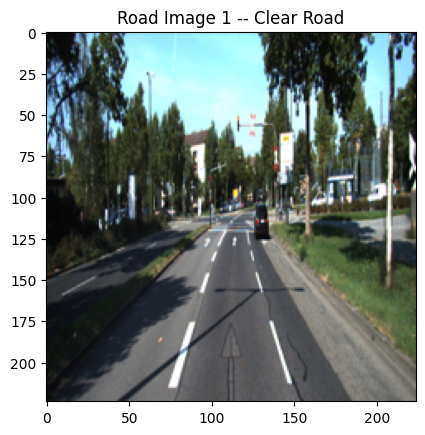

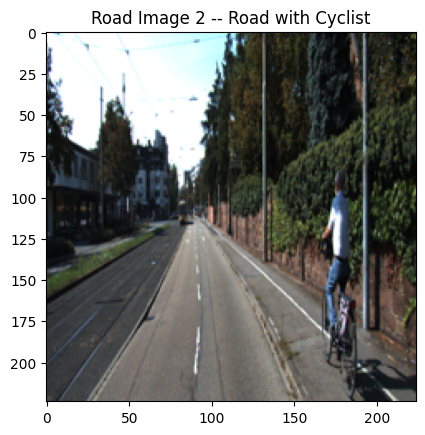

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.signal import convolve2d

# load both road images
im1 = cv.imread('/content/drive/MyDrive/HWPictures/laneImage2.png')
im2 = cv.imread('/content/drive/MyDrive/HWPictures/laneImage1.png')

img1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
img2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

plt.figure()
plt.title('Road Image 1 -- Clear Road')
plt.imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB))
plt.show()

plt.figure()
plt.title('Road Image 2 -- Road with Cyclist')
plt.imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB))
plt.show()

---
# Step 1: Average Filter
**MY WORK — from Iris/Circle demo and Filtering HW**

First I smooth both images with an average filter using the same 10x10 kernel from the iris demo. Road images have a lot of texture noise from the asphalt surface, so smoothing first makes the edge detection much cleaner. I also define make_g_kern here from the filtering homework in case it's needed later.

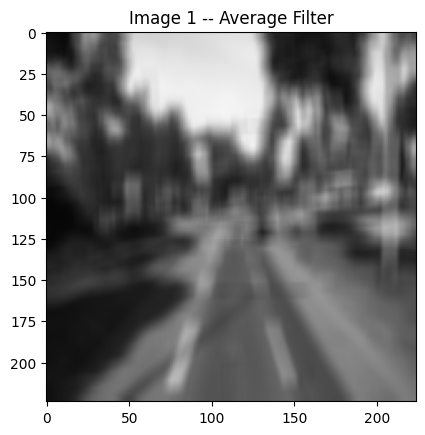

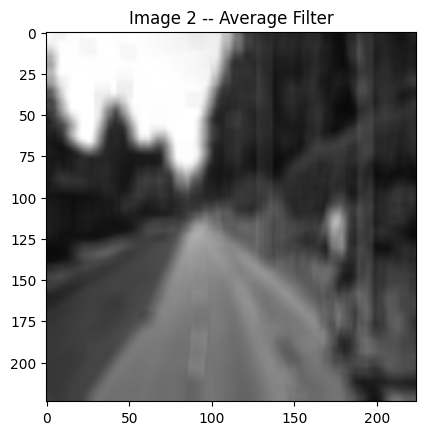

In [ ]:
# MY WORK Gaussian kernel -- from Filtering HW
def make_g_kern(size, sigma):
    kern = cv.getGaussianKernel(size*2+1, sigma)
    return np.outer(kern, kern)

# average filter -- same as iris demo
average_kernel = np.array(
    [[0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
    [0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01]]
)

average1 = cv.filter2D(img1, -1, average_kernel)
average2 = cv.filter2D(img2, -1, average_kernel)

plt.figure()
plt.title('Image 1 -- Average Filter')
plt.imshow(average1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Average Filter')
plt.imshow(average2, cmap='gray', vmin=0, vmax=255)
plt.show()

---
# Step 2: Sobel Edge Detection
**MY WORK — from Iris/Circle demo**

I apply Sobel edge detection the same way as the iris demo. The vertical Sobel kernel is especially useful here since lane lines run mostly vertically in a forward-facing road image. I combine horizontal and vertical responses into a single edge magnitude image using the square root of the sum of squares, then normalize. The output shows bright edges along the lane markings.

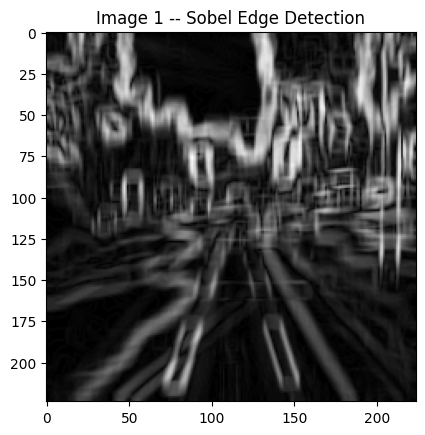

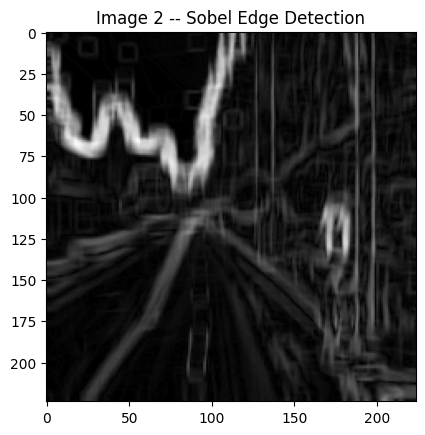

In [ ]:
# MY WORK Sobel edge detection -- exactly from Iris demo

sobel_vert = np.array([
     [-1.0, 0.0, 1.0]
    ,[-2.0, 0.0, 2.0]
    ,[-1.0, 0.0, 1.0]
    ])
sobel_horiz = sobel_vert.T

def sobel_edges(img):
    d_horiz = convolve2d(img, sobel_horiz, mode='same', boundary='symm', fillvalue=0)
    d_vert  = convolve2d(img, sobel_vert,  mode='same', boundary='symm', fillvalue=0)
    edgel = np.sqrt(np.square(d_horiz) + np.square(d_vert))
    edgel *= 255.0 / np.max(edgel)
    return edgel

edgel1 = sobel_edges(average1)
edgel2 = sobel_edges(average2)

plt.figure()
plt.title('Image 1 -- Sobel Edge Detection')
plt.imshow(edgel1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Sobel Edge Detection')
plt.imshow(edgel2, cmap='gray', vmin=0, vmax=255)
plt.show()

---
# Step 3: Brightness Thresholding to Isolate Lane Pixels
**MY WORK — from Skin Detection HW**

Lane markings are white (or bright) on dark asphalt, so I can use a brightness threshold to isolate them, the same idea as the skin detection homework where I checked pixel channel conditions to classify regions. Here I check if a pixel is bright enough to be a lane marking. I apply the threshold to the grayscale image directly, looking for pixels above a brightness value that corresponds to the white lane markings.

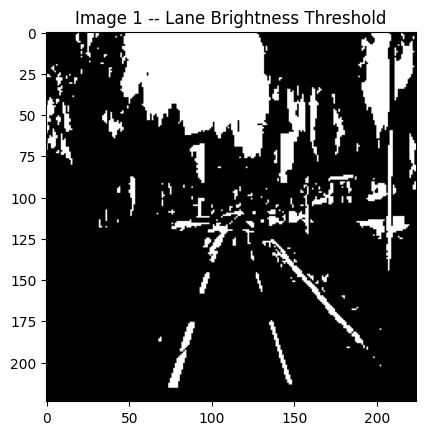

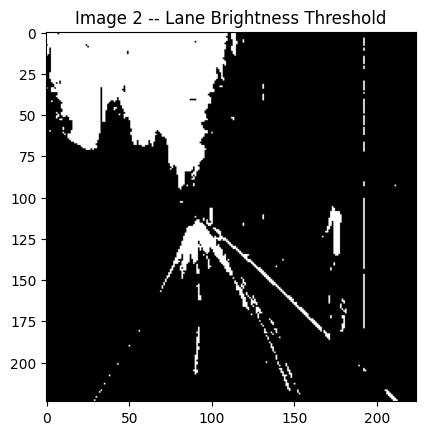

In [ ]:
# MY WORK Lane brightness threshold -- from the Skin detection HW
# Lane markings are white/bright so high brightness pixels are likely lane pixels
def lane_threshold(src):
    src = src.astype(np.int16)
    mean_val = src.mean()

    # condition: pixel must be significantly brighter than the image mean
    lane_mask = (src > mean_val + 40) & (src > 150)

    result = np.zeros_like(src, dtype=np.uint8)
    result[lane_mask] = 255
    return result

lane_mask1 = lane_threshold(img1)
lane_mask2 = lane_threshold(img2)

plt.figure()
plt.title('Image 1 -- Lane Brightness Threshold')
plt.imshow(lane_mask1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Lane Brightness Threshold')
plt.imshow(lane_mask2, cmap='gray', vmin=0, vmax=255)
plt.show()

---
# Step 4: Region of Interest (ROI) Mask
**MY WORK — from Iris/Circle demo**

One of the biggest false detections in lane detection is the sky, trees, and buildings in the upper part of the image. Since lanes only appear in the lower portion of the road image, I apply a region of interest mask to cut out everything above the horizon line. This is the same masking approach from the iris demo where it used nested loops and `in_circle` to zero out pixels outside the region of interest, here it was for a rectangular region instead of a circle.

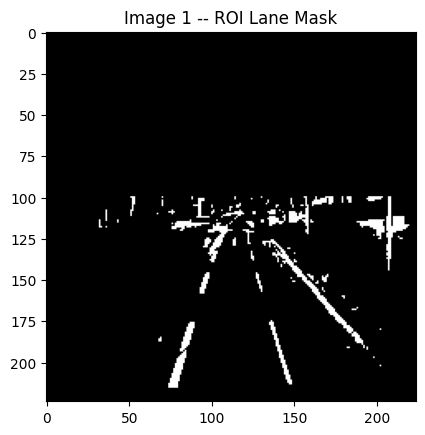

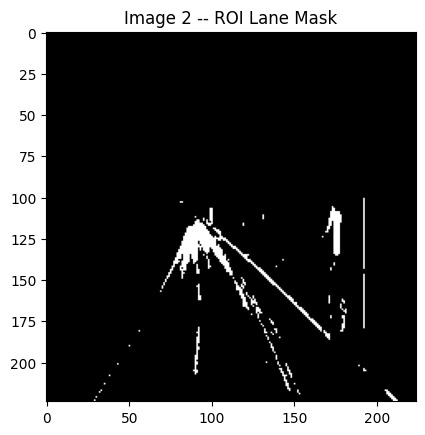

In [ ]:
# MY WORK and Help from AI Region of interest mask -- adapted from iris demo mask approach
# Zero out the upper half of the image where lanes don't appear
def apply_roi(src, start_row_fraction=0.45):

    dst = src.copy()
    rows, cols = src.shape
    start_row = int(rows * start_row_fraction)
    for ii in range(rows):
        for jj in range(cols):
            if ii < start_row:
                dst[ii][jj] = 0
    return dst

roi_mask1 = apply_roi(lane_mask1)
roi_mask2 = apply_roi(lane_mask2)

roi_edge1 = apply_roi(edgel1.astype(np.uint8))
roi_edge2 = apply_roi(edgel2.astype(np.uint8))

plt.figure()
plt.title('Image 1 -- ROI Lane Mask')
plt.imshow(roi_mask1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- ROI Lane Mask')
plt.imshow(roi_mask2, cmap='gray', vmin=0, vmax=255)
plt.show()

---
# Step 5: Morphological Open and Close
**[MY WORK] — from Skin Detection HW**

Following the same sequence as the skin detection homework, I apply morphological opening to remove small noise blobs from the lane mask, then closing to fill in gaps within the lane regions. The kernel sizes (2x2 for open, 8x8 for close) match the skin detection homework. The output is a cleaner binary mask showing where the lane markings are.

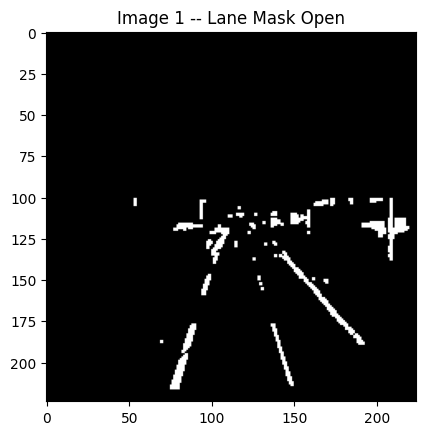

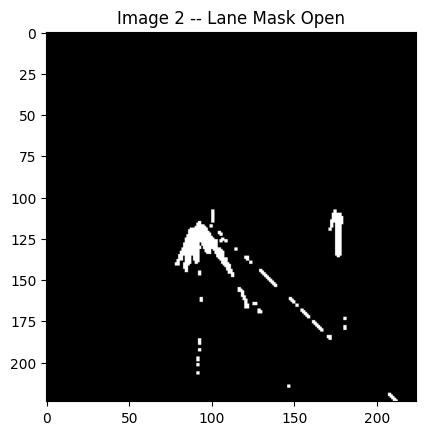

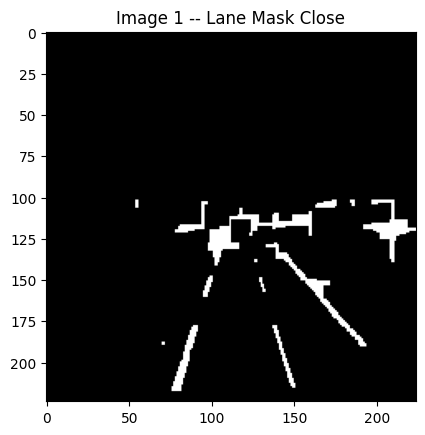

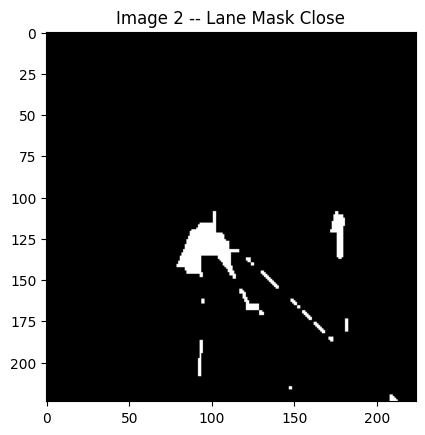

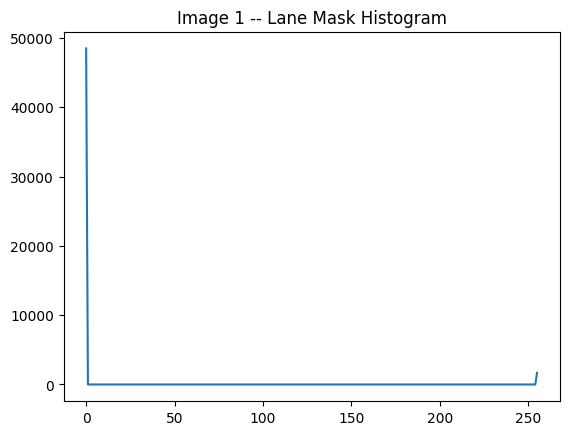

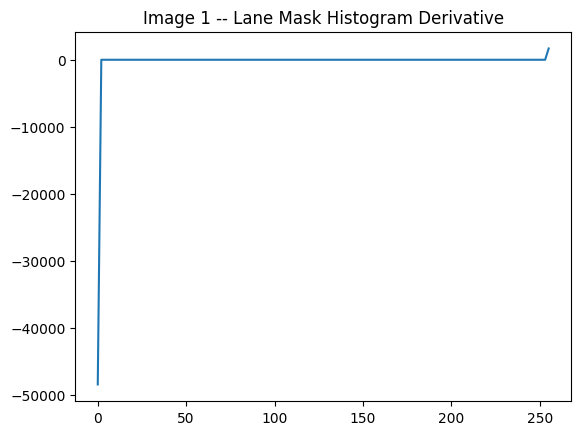

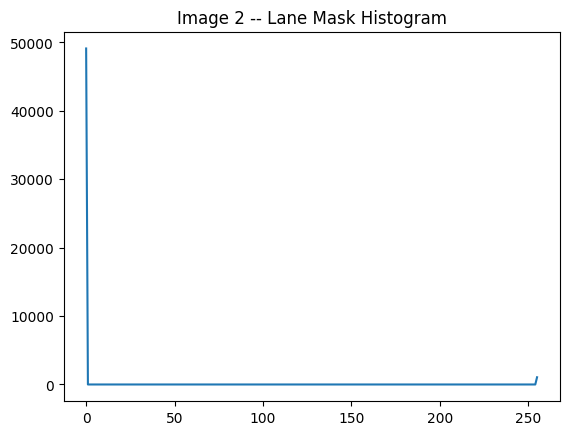

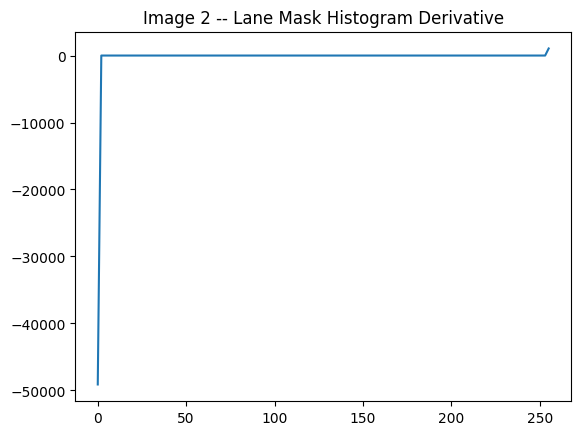

In [ ]:
# MY WORK Morphological open/close + histogram -- exactly from Skin Detection HW

kernel = np.ones((2,2), np.uint8)
opening1 = cv.morphologyEx(roi_mask1, cv.MORPH_OPEN, kernel)
opening2 = cv.morphologyEx(roi_mask2, cv.MORPH_OPEN, kernel)

plt.figure()
plt.title('Image 1 -- Lane Mask Open')
plt.imshow(opening1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Lane Mask Open')
plt.imshow(opening2, cmap='gray', vmin=0, vmax=255)
plt.show()

kernel = np.ones((8,8), np.uint8)
closing1 = cv.morphologyEx(opening1, cv.MORPH_CLOSE, kernel)
closing2 = cv.morphologyEx(opening2, cv.MORPH_CLOSE, kernel)

plt.figure()
plt.title('Image 1 -- Lane Mask Close')
plt.imshow(closing1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Lane Mask Close')
plt.imshow(closing2, cmap='gray', vmin=0, vmax=255)
plt.show()

# histogram -- same as skin detection HW
hist1 = cv.calcHist([closing1], [0], None, [256], [0,256])
hist2 = cv.calcHist([closing2], [0], None, [256], [0,256])
bins = np.arange(256)
deriv1 = np.gradient(hist1.flatten())
deriv2 = np.gradient(hist2.flatten())

plt.figure()
plt.plot(bins[:256], hist1)
plt.title('Image 1 -- Lane Mask Histogram')
plt.show()

plt.figure()
plt.plot(bins[:256], deriv1)
plt.title('Image 1 -- Lane Mask Histogram Derivative')
plt.show()

plt.figure()
plt.plot(bins[:256], hist2)
plt.title('Image 2 -- Lane Mask Histogram')
plt.show()

plt.figure()
plt.plot(bins[:256], deriv2)
plt.title('Image 2 -- Lane Mask Histogram Derivative')
plt.show()

---
# Step 6: Contour Detection
**MY WORK — from Contour HW**

Using `cv.findContours` and `cv.convexHull` exactly as in the contour homework to outline the detected lane regions. This gives a clean visualization of where the lane blobs are in the image and confirms the masking and morphology steps are working correctly.

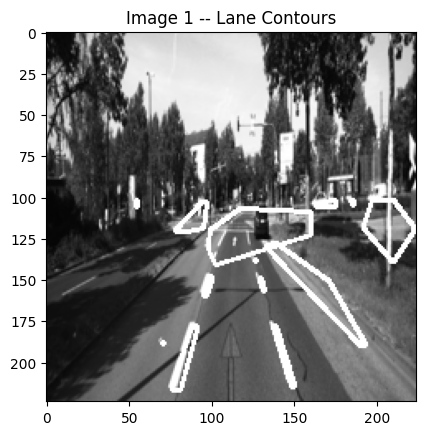

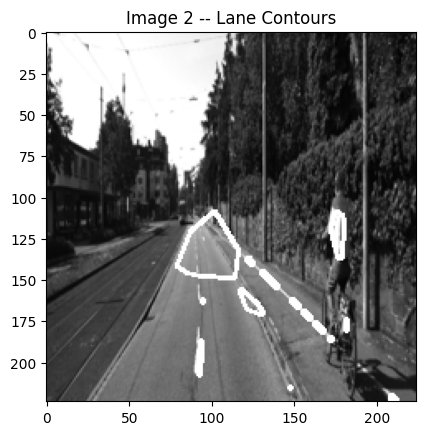

In [ ]:
# MY WORK and AI Contours and convex hulls -- exactly from Contour HW
# the first 3 lines in the function are from AI

def draw_contours(gray_img, mask):
    ret, thresh = cv.threshold(mask, 127, 255, 0)
    contours, hierarchy = cv.findContours(thresh, 1, 2)
    image = gray_img.copy()
    for contour in contours:
        convexHull = cv.convexHull(contour)
        cv.drawContours(image, [convexHull], -1, (255, 0, 0), 2)
    return image

contour_img1 = draw_contours(img1, closing1)
contour_img2 = draw_contours(img2, closing2)

plt.figure()
plt.title('Image 1 -- Lane Contours')
plt.imshow(contour_img1, cmap='gray', vmin=0, vmax=255)
plt.show()

plt.figure()
plt.title('Image 2 -- Lane Contours')
plt.imshow(contour_img2, cmap='gray', vmin=0, vmax=255)
plt.show()

---
# Step 7: Hough Line Transform
**MY WORK — from class example**

Following the class example for Hough Line Transform, I apply Canny edge detection on the ROI-masked edge image and then run `cv.HoughLines` to detect the lane lines. The threshold was tuned for these road images — lane lines produce strong, consistent edges so the threshold can be set relatively high to avoid picking up noise. The drawing loop is the same as the class example and the midterm project.

Lines found: 10
Lines found: 8


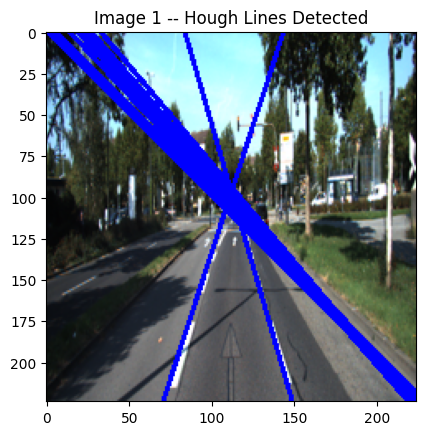

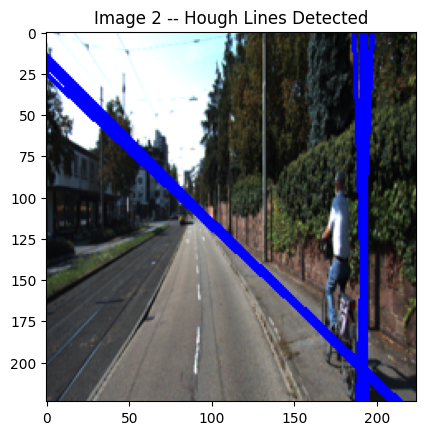

In [ ]:
# MY WORK Hough Line Transform

def detect_hough_lines(im_color, gray_img, threshold=80):
    edges = cv.Canny(gray_img, 50, 150, apertureSize=3)
    lines = cv.HoughLines(edges, 1, np.pi/180, threshold)
    img_lines = cv.cvtColor(im_color, cv.COLOR_BGR2RGB).copy()

    if lines is not None:
        for rho, theta in lines[:,0]:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a*rho
            y0 = b*rho
            x1 = int(x0 + 1000*(-b))
            y1 = int(y0 + 1000*(a))
            x2 = int(x0 - 1000*(-b))
            y2 = int(y0 - 1000*(a))
            cv.line(img_lines, (x1,y1), (x2,y2), (0,0,255), 2)
        print('Lines found:', len(lines))
    else:
        print('No lines found')
    return img_lines

hough1 = detect_hough_lines(im1, roi_mask1, threshold=50)
hough2 = detect_hough_lines(im2, roi_mask2, threshold=50)

plt.figure()
plt.title('Image 1 -- Hough Lines Detected')
plt.imshow(hough1)
plt.show()

plt.figure()
plt.title('Image 2 -- Hough Lines Detected')
plt.imshow(hough2)
plt.show()

---
# Step 8: Lane Overlay on Original Image
**[AI ASSISTED]**

This final visualization overlays the detected lane mask back onto the original color image using a green tint to highlight the lane region. This step was written with AI assistance and is labeled as such. Everything prior to this step is my own work.

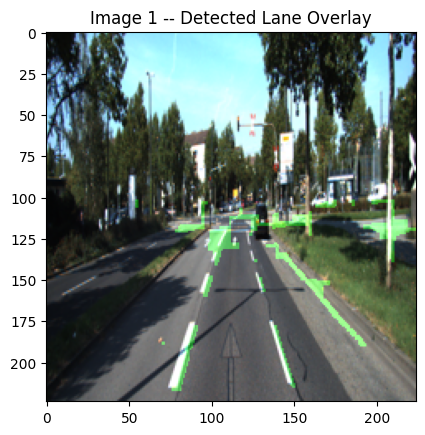

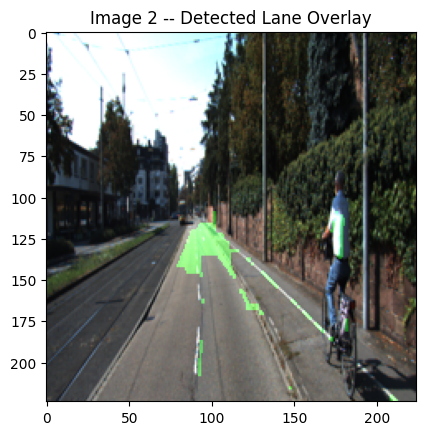

In [ ]:
# [AI ASSISTED] Lane overlay visualization

def lane_overlay(im_color, lane_mask):
    img_out = cv.cvtColor(im_color, cv.COLOR_BGR2RGB).copy()
    overlay = np.zeros_like(img_out)
    overlay[:,:,1] = lane_mask  # green channel
    img_out = cv.addWeighted(img_out, 1.0, overlay, 0.4, 0)
    return img_out

overlay1 = lane_overlay(im1, closing1)
overlay2 = lane_overlay(im2, closing2)

plt.figure()
plt.title('Image 1 -- Detected Lane Overlay')
plt.imshow(overlay1)
plt.show()

plt.figure()
plt.title('Image 2 -- Detected Lane Overlay')
plt.imshow(overlay2)
plt.show()